# 03. 해외ETF(PREF02N001) EDA

스냅샷 파일 기준일: **2026-07-11** / 원본 5,646행 × 49컬럼

이 테이블은 **스키마에 한글 컬럼명(name_ko)이 전혀 없다.** 따라서 첫 작업은
국내ETF 스키마와의 동명 컬럼 매칭 + 해외 전용 컬럼 직접 해석으로 **한글 컬럼 사전을 만드는 것**이며,
결과를 `EDA/etf_gl_column_names.csv`로 저장해 COLUMN_GUIDE 입력으로 쓴다.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)

ROOT = Path.cwd()
while not (ROOT / "data" / "csv").exists():
    ROOT = ROOT.parent
CSV = ROOT / "data" / "csv"
OUT = ROOT / "EDA"

df = pd.read_csv(CSV / "PREF02N001_etf_gl_master_20260711.csv", dtype=str, keep_default_na=False)
schema = pd.read_csv(CSV / "PREF02N001_etf_gl_schema_20260711.csv", dtype=str, keep_default_na=False)
kr_schema = pd.read_csv(CSV / "PREF01N001_etf_kr_schema_20260711.csv", dtype=str, keep_default_na=False)
print(df.shape, schema.shape)
print("name_ko 채워진 컬럼 수:", int((schema.name_ko != "").sum()), "/", len(schema))

(5646, 49) (49, 5)
name_ko 채워진 컬럼 수: 0 / 49


In [2]:
def num(s):
    return pd.to_numeric(s, errors="coerce")

## 1. 한글 컬럼명 부여 → `etf_gl_column_names.csv`

In [3]:
kr_ko = dict(zip(kr_schema.column, kr_schema.name_ko))
shared = [c for c in schema.column if c in kr_ko and kr_ko[c]]
only_gl = [c for c in schema.column if c not in shared]
print("국내ETF 스키마에서 한글명 상속 가능:", len(shared), "컬럼")
print("해외 전용(직접 해석 필요)      :", len(only_gl), "컬럼")
print(only_gl)

국내ETF 스키마에서 한글명 상속 가능: 36 컬럼
해외 전용(직접 해석 필요)      : 13 컬럼
['cu_etn_yn', 'cu_index_repl_mthd', 'cu_index_tracking_yn', 'cu_inverse_short_yn', 'du_base_dt_match_yn', 'du_clpr_base_dt', 'du_clpr_src', 'du_nav_base_dt', 'du_opr', 'pd_isin_cd', 'pd_lipper_id', 'pd_trd_ccy', 'pd_us_cik']


In [4]:
# 해외 전용 컬럼은 값 실측을 근거로 직접 해석해 부여한다.
GL_ONLY_KO = {
    "cu_etn_yn": ("ETN여부", "값이 'Y' 59건뿐이고 pd_grp_no=='ETN'과 정확히 일치"),
    "cu_index_repl_mthd": ("지수복제방식", "Optimized/Swap/Full/Other — 국내 cu_strtegy의 실물/합성에 대응"),
    "cu_index_tracking_yn": ("지수추종여부", "'Y' 또는 결측만 존재, cu_index_repl_mthd 유무와 결측 패턴 동일"),
    "cu_inverse_short_yn": ("인버스/숏여부", "'Y' 171건, 상품명의 Inverse/Short/Bear와 대응"),
    "du_base_dt_match_yn": ("종가·NAV기준일일치여부", "전 행 'N' — 종가일과 NAV일이 다름을 뜻하는 상수 플래그"),
    "du_clpr_base_dt": ("종가기준일자", "YYYYMMDD, du_upt_dt와 거의 동일하나 stale 종목 존재"),
    "du_clpr_src": ("종가출처", "전 행 'pd65n101.tday_clpr' — 사내 적재 테이블명"),
    "du_nav_base_dt": ("NAV기준일자", "timestamp, du_clpr_base_dt와 쌍"),
    "du_opr": ("시가", "국내 du_lpr(시가)과 다른 이름을 씀 — open price"),
    "pd_isin_cd": ("ISIN코드", "국제증권식별번호 12자리, 외부 조인 표준키"),
    "pd_lipper_id": ("Lipper펀드ID", "LSEG Lipper 식별자, 외부 펀드 DB 조인키"),
    "pd_trd_ccy": ("거래통화", "전 행 USD"),
    "pd_us_cik": ("미국SEC CIK", "SEC EDGAR 등록번호 — N-PORT 구성종목 취득의 유일 경로"),
}
guide = pd.DataFrame({"column": schema.column, "dtype": schema.dtype})
guide["name_ko"] = [kr_ko.get(c, "") or GL_ONLY_KO.get(c, ("", ""))[0] for c in guide.column]
guide["출처"] = ["국내ETF스키마 상속" if c in shared else "직접해석" if c in GL_ONLY_KO else "미상" for c in guide.column]
guide["근거/비고"] = [GL_ONLY_KO.get(c, ("", ""))[1] for c in guide.column]
guide["결측률"] = [round((df[c] == "").mean(), 4) for c in guide.column]
guide["고유값수"] = [int(df[c][df[c] != ""].nunique()) for c in guide.column]
guide

,column,dtype,name_ko,출처,근거/비고,결측률,고유값수
0,cu_base_index,text,기초지수,국내ETF스키마 상속,,0.0014,1733
1,cu_charge_rt,numeric,총보수요율,국내ETF스키마 상속,,0.0000,127
2,cu_etn_yn,text,ETN여부,직접해석,값이 'Y' 59건뿐이고 pd_grp_no=='ETN'과 정확히 일치,0.9896,1
3,cu_fund_mgmt_co,text,운용사,국내ETF스키마 상속,,0.0014,372
4,cu_index_repl_mthd,text,지수복제방식,직접해석,Optimized/Swap/Full/Other — 국내 cu_strtegy의 실물/합성에 대응,0.5820,4
5,cu_index_tracking_yn,text,지수추종여부,직접해석,"'Y' 또는 결측만 존재, cu_index_repl_mthd 유무와 결측 패턴 동일",0.5820,1
6,cu_inverse_short_yn,text,인버스/숏여부,직접해석,"'Y' 171건, 상품명의 Inverse/Short/Bear와 대응",0.9697,1
7,cu_lev_fector,numeric,배수,국내ETF스키마 상속,,1.0000,0
8,cu_strtegy,text,운용전략,국내ETF스키마 상속,,0.0014,5566
9,cu_upt_dt,text,변동갱신일자,국내ETF스키마 상속,,0.0000,1


In [5]:
assert (guide.name_ko == "").sum() == 0, "한글명 미부여 컬럼 존재"
guide.to_csv(OUT / "etf_gl_column_names.csv", index=False, encoding="utf-8-sig")
print("저장:", OUT / "etf_gl_column_names.csv", "|", len(guide), "행")

저장: /mnt/c/Users/rladl/Desktop/2026_MIRAE_ASSET_AI-Festival/2026_10th_MIRAE-ASSET_AI-Festival/EDA/etf_gl_column_names.csv | 49 행


> **시사점:** 49개 컬럼 중 36개는 국내ETF 스키마에서 한글명을 그대로 상속할 수 있어 **두 테이블은 같은 스키마 계보**임이 확인된다. 나머지 13개가 해외 전용이며 그 성격이 곧 해외ETF의 강점이다 — **ISIN·Lipper ID·SEC CIK 같은 외부 조인키와 지수복제방식이 국내ETF에는 아예 없다.** 생성한 `etf_gl_column_names.csv`는 COLUMN_GUIDE(자연어→컬럼 매핑)의 입력이 된다.

## 2. ETF / ETN 분리

In [6]:
print(df.pd_grp_no.value_counts().to_string())
print()
print(pd.crosstab(df.pd_grp_no, df.cu_etn_yn.replace("", "(결측)")).to_string())
etf = df[df.pd_grp_no == "ETF"].copy()
print("\nETF:", len(etf), "/ ETN:", int((df.pd_grp_no == "ETN").sum()))

pd_grp_no
ETF    5587
ETN      59



cu_etn_yn  (결측)   Y
pd_grp_no          
ETF        5587   0
ETN           0  59



ETF: 5587 / ETN: 59


> **시사점:** 해외분은 ETN이 59건(1.0%)뿐이라 국내(30.7%)와 오염 정도가 전혀 다르다. `cu_etn_yn`과 `pd_grp_no`가 완전 일치하므로 둘 중 하나만 온톨로지에 싣는다.

## 3. 거래소 · 시장

In [7]:
print(df.pd_exg_mkt_cd.value_counts().to_string())
print("\npd_mkt_id:", df.pd_mkt_id.value_counts().to_dict())
print("pd_trd_ccy:", df.pd_trd_ccy.value_counts().to_dict())
print("pd_curr_cd:", df.pd_curr_cd.replace("", "(결측)").value_counts().to_dict())

pd_exg_mkt_cd
AMX    4241
NAS    1296
NYS      78
102      22
101       9

pd_mkt_id: {'US': 5646}
pd_trd_ccy: {'USD': 5646}
pd_curr_cd: {'USD': 5637, '(결측)': 8, 'INR': 1}


In [8]:
# 숫자 거래소코드('102','101')는 코드 체계 오염
bad = df[df.pd_exg_mkt_cd.str.fullmatch(r"\d+")]
print("숫자형 거래소코드:", len(bad), "건")
bad[["pd_itm_no", "pd_nm", "pd_exg_mkt_cd", "pd_isin_cd", "pd_lstg_dt"]].head(10)

숫자형 거래소코드: 31 건


,pd_itm_no,pd_nm,pd_exg_mkt_cd,pd_isin_cd,pd_lstg_dt
107,EUSM.K,Eventide US Market ETF,102,US86280R7879,20241217
676,LDER.K,LifeX 2040 Term Income ETF,102,US86172A2565,20250103
994,PTEC.O,Global X PropTech ETF,101,US37960A5948,20230411
1499,NBCC.K,Neuberger Berman Next Gen Conn Consumer ETF,102,US64135A3095,20220406
1633,DWCR.K,Arrow DWA Tactical: International ETF,102,US0427656857,20171229
1825,FIBR.K,iShares US Fixed Inc Balanced Risk Systematic ETF,102,US46435U7963,20150224
2011,MNTL.O,Tema Neuroscience and Mental Health ETF,101,US87975E8755,20240122
2162,RAYS.O,Global X Solar ETF,101,US37960A7019,20210908
2268,IEQ,Lazard International Dynamic Equity ETF,102,US52110K4004,20150529
2378,LUX,Tema Luxury ETF,102,US87975E3053,20230510


> **시사점:** 거래소는 AMX 4,241 / NAS 1,296 / NYS 78의 3자 코드 체계인데 **`102`·`101` 같은 숫자 코드 31건이 섞여 있다**(다른 코드 체계가 그대로 흘러들어온 오염). 온톨로지의 `Exchange` 인스턴스는 3자 코드만 허용하고 숫자 코드는 매핑 실패로 격리해야 한다. `pd_curr_cd`에는 USD가 아닌 `INR` 1건이 있으나 실제 거래통화(`pd_trd_ccy`)는 전 행 USD라, **통화 질의에는 `pd_trd_ccy`를 써야 한다.**

## 4. 문자열 sentinel — 겉보기 결측률의 함정

In [9]:
print("cu_base_index 겉보기 결측률: %.4f" % (df.cu_base_index == "").mean())
df.cu_base_index.replace("", "(빈문자열)").value_counts().head(8).to_frame("건수")

cu_base_index 겉보기 결측률: 0.0014


,건수
cu_base_index,
Index is not provided by Management Company,1984
Index is not available on Lipper Database,721
S&P 500 TR,335
Bloomberg U.S. Aggregate Bond TR,89
S&P 500 CR,51
Russell 1000 Growth TR,35
Russell 1000 Value TR,34
MSCI EAFE NR USD,28


In [10]:
SENTINELS = [
    "Index is not provided by Management Company",
    "Index is not available on Lipper Database",
]
is_sent = df.cu_base_index.isin(SENTINELS) | (df.cu_base_index == "")
pd.DataFrame(
    [
        {"구분": "빈 문자열", "건수": int((df.cu_base_index == "").sum())},
        {"구분": SENTINELS[0], "건수": int((df.cu_base_index == SENTINELS[0]).sum())},
        {"구분": SENTINELS[1], "건수": int((df.cu_base_index == SENTINELS[1]).sum())},
        {"구분": "── 실질 결측 합계", "건수": int(is_sent.sum())},
        {"구분": "실제 지수명 보유", "건수": int((~is_sent).sum())},
    ]
).assign(비율=lambda t: (t.건수 / len(df)).round(4))

,구분,건수,비율
0,빈 문자열,8,0.0014
1,Index is not provided by Management Company,1984,0.3514
2,Index is not available on Lipper Database,721,0.1277
3,── 실질 결측 합계,2713,0.4805
4,실제 지수명 보유,2933,0.5195


In [11]:
print("겉보기 결측률: %.1f%%  →  실질 결측률: %.1f%%" % ((df.cu_base_index == "").mean() * 100, is_sent.mean() * 100))
print("\n실제 지수명 상위:")
print(df.loc[~is_sent, "cu_base_index"].value_counts().head(15).to_string())
print("\n고유 지수명 수:", df.loc[~is_sent, "cu_base_index"].nunique())

겉보기 결측률: 0.1%  →  실질 결측률: 48.1%

실제 지수명 상위:
cu_base_index
S&P 500 TR                                  335
Bloomberg U.S. Aggregate Bond TR             89
S&P 500 CR                                   51
Russell 1000 Growth TR                       35
Russell 1000 Value TR                        34
MSCI EAFE NR USD                             28
Russell 3000 TR                              27
MSCI EM (Emerging Markets) NR USD            25
NASDAQ 100 TR                                25
Russell 2000 TR                              25
MSCI AC World ex USA NR USD                  20
MSCI AC World NR USD                         19
Bloomberg Municipal Bond TR                  17
S&P Mid Cap 400 TR                           12
ICE BofA US 3-Month Treasury Bill TR USD     11

고유 지수명 수: 1731


In [12]:
# 같은 함정: cu_strtegy는 코드가 아니라 투자설명서 문장(자유 텍스트)이다.
print("cu_strtegy 고유값 수:", df.cu_strtegy.nunique(), "/ 평균 길이:", int(df.cu_strtegy.str.len().mean()), "자")
print("\n예시:")
for s in df.cu_strtegy[df.cu_strtegy != ""].head(2):
    print(" -", s[:180], "...")

cu_strtegy 고유값 수: 5567 / 평균 길이: 309 자

예시:
 - The Fund seeks to track the price and yield performance, before fees and expenses, of the WisdomTree U.S. SmallCap Earnings Index. The Index is a fundamentally weighted index that  ...
 - The Fund seeks to track the performance, before fees and expenses, of the Change Finance Diversified Impact U.S. Large Cap Fossil Fuel Free Index which measures the performance of  ...


> **시사점:** `cu_base_index`의 빈 문자열은 0.14%지만, **"Index is not provided by Management Company"(1,984) · "Index is not available on Lipper Database"(721)라는 문장형 sentinel을 더하면 실질 결측률은 약 48%**로 뛴다. 이 문자열을 지수명으로 오인하면 "이 ETF의 기초지수는 Index is not provided…입니다"라는 답이 나간다 — **ETL 단계에서 sentinel 목록을 명시적으로 NULL 처리**해야 한다. `cu_strtegy` 역시 국내와 달리 코드값이 아니라 투자설명서 원문 문장이므로, 분류 축이 아니라 **RAG 검색 대상 텍스트**로 취급해야 한다.

## 5. 총보수(cu_charge_rt) — 국내와 정반대의 커버리지

In [13]:
ch = num(df.cu_charge_rt)
print("cu_charge_rt 결측률: %.4f (건수 %d)" % ((df.cu_charge_rt == "").mean(), (df.cu_charge_rt == "").sum()))
print()
print(ch.describe().round(4).to_string())
print("\n총보수 0% 상품:", int((ch == 0).sum()), "건")

cu_charge_rt 결측률: 0.0000 (건수 0)

count    5646.0000
mean        0.5018
std         0.3472
min         0.0000
25%         0.2000
50%         0.4900
75%         0.7500
max         2.5000

총보수 0% 상품: 363 건


In [14]:
pd.cut(ch, [-0.001, 0, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 3.0],
       labels=["0", "0-0.1", "0.1-0.2", "0.2-0.35", "0.35-0.5", "0.5-0.75", "0.75-1.0", "1.0+"]).value_counts().sort_index().to_frame("건수")

,건수
cu_charge_rt,
0,363
0-0.1,512
0.1-0.2,545
0.2-0.35,767
0.35-0.5,1003
0.5-0.75,1270
0.75-1.0,903
1.0+,283


In [15]:
kr = pd.read_csv(CSV / "PREF01N001_etf_kr_master_20260711.csv", dtype=str, keep_default_na=False)
kr_etf = kr[kr.pd_grp_no == "ETF"]
pd.DataFrame(
    [
        {"데이터셋": "국내ETF", "행수": len(kr_etf), "총보수 결측률": round((kr_etf.cu_charge_rt == "").mean(), 4),
         "기초지수 결측률(실질)": round((kr_etf.cu_base_index == "").mean(), 4)},
        {"데이터셋": "해외ETF", "행수": len(etf), "총보수 결측률": round((etf.cu_charge_rt == "").mean(), 4),
         "기초지수 결측률(실질)": round(is_sent[etf.index].mean(), 4)},
    ]
)

,데이터셋,행수,총보수 결측률,기초지수 결측률(실질)
0,국내ETF,1202,0.8195,0.9517
1,해외ETF,5587,0.0000,0.4824


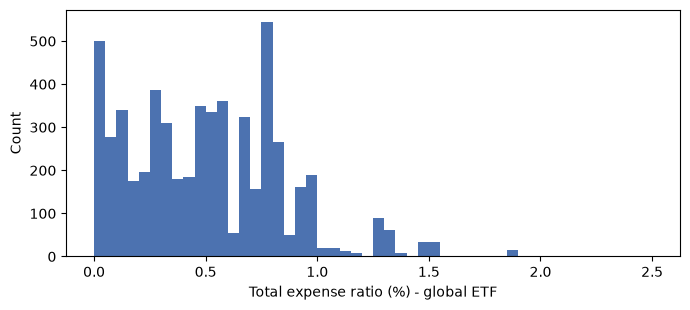

In [16]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ch.plot.hist(bins=50, ax=ax, color="#4C72B0")
ax.set_xlabel("Total expense ratio (%) - global ETF")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

> **시사점:** 해외ETF는 **총보수 결측 0%**(중앙값 0.49%, 0% 상품 363건)로, 결측 81.9%인 국내ETF와 커버리지가 정확히 반대다. 반대로 기초지수는 국내가 95% 결측, 해외가 48% 결측이다. 따라서 **"보수가 싼 ETF" 질의는 해외ETF에만 답할 수 있고**, 국내·해외를 한 답변에 섞으면 국내 상품이 부당하게 누락된다. 온톨로지에서 `expenseRatio`는 공통 속성으로 두되, **커버리지 편향을 RAG 응답 정책에 명시**해야 한다.

## 6. 지수복제방식 · 인버스 · 레버리지

In [17]:
pd.DataFrame(
    {
        "cu_index_repl_mthd(지수복제방식)": df.cu_index_repl_mthd.replace("", "(결측)").value_counts(),
        "cu_index_tracking_yn(지수추종)": df.cu_index_tracking_yn.replace("", "(결측)").value_counts(),
        "cu_inverse_short_yn(인버스/숏)": df.cu_inverse_short_yn.replace("", "(결측)").value_counts(),
        "cu_lev_fector(배수)": df.cu_lev_fector.replace("", "(결측)").value_counts(),
    }
)

,cu_index_repl_mthd(지수복제방식),cu_index_tracking_yn(지수추종),cu_inverse_short_yn(인버스/숏),cu_lev_fector(배수)
(결측),3286.0,3286.0,5475.0,5646.0
Full,263.0,NaN,NaN,NaN
Optimized,1802.0,NaN,NaN,NaN
Other,6.0,NaN,NaN,NaN
Swap,289.0,NaN,NaN,NaN
Y,NaN,2360.0,171.0,NaN


In [18]:
# 복제방식 결측 = 지수추종 아님(액티브)인지 확인
print(pd.crosstab(df.cu_index_repl_mthd.replace("", "(결측)"), df.cu_index_tracking_yn.replace("", "(결측)")).to_string())
print("\n복제방식 결측 & 기초지수 sentinel:", int((df.cu_index_repl_mthd == "").sum() and ((df.cu_index_repl_mthd == "") & is_sent).sum()))
print("복제방식 유효 & 기초지수 sentinel:", int(((df.cu_index_repl_mthd != "") & is_sent).sum()))

cu_index_tracking_yn  (결측)     Y
cu_index_repl_mthd              
(결측)                  3286     0
Full                     0   263
Optimized                0  1802
Other                    0     6
Swap                     0   289

복제방식 결측 & 기초지수 sentinel: 2168
복제방식 유효 & 기초지수 sentinel: 545


In [19]:
# 레버리지 배수는 전량 결측 → 상품명에서만 복원 가능
print("cu_lev_fector 전량 결측:", (df.cu_lev_fector == "").all())
for pat, lab in [(r"\b2X\b|\bUltra\b", "2X"), (r"\b3X\b", "3X"), (r"Inverse|\bBear\b|\bShort\b", "인버스")]:
    print(f"  상품명 '{lab}' 패턴: {int(df.pd_nm.str.contains(pat, case=False, regex=True).sum())}건")
print("\ncu_inverse_short_yn='Y' 이면서 상품명에 Inverse/Bear/Short 없는 건:",
      int(((df.cu_inverse_short_yn == "Y") & ~df.pd_nm.str.contains("Inverse|Bear|Short", case=False)).sum()))

cu_lev_fector 전량 결측: True
  상품명 '2X' 패턴: 576건
  상품명 '3X' 패턴: 64건
  상품명 '인버스' 패턴: 260건

cu_inverse_short_yn='Y' 이면서 상품명에 Inverse/Bear/Short 없는 건: 5


> **시사점:** `cu_index_repl_mthd`(Optimized 1,802 / Swap 289 / Full 263)와 `cu_index_tracking_yn`은 **결측 패턴이 완전히 동일**해, 결측 3,286건 = "지수를 추종하지 않는 액티브형"으로 읽는 것이 타당하다. 즉 결측 자체가 정보다. 반면 **`cu_lev_fector`(배수)는 전량 결측**이라 국내ETF와 달리 레버리지 축을 컬럼으로 만들 수 없고 **상품명 정규식(2X/3X/Ultra/Bear)** 이 유일한 경로다.

## 7. 자산군 · 투자지역 — 국내와의 체계 불일치

In [20]:
pd.DataFrame(
    {
        "해외ETF wu_inv_ast_type": df.wu_inv_ast_type.replace("", "(결측)").value_counts(),
        "국내ETF wu_inv_ast_type": kr_etf.wu_inv_ast_type.replace("", "(결측)").value_counts(),
    }
)

,해외ETF wu_inv_ast_type,국내ETF wu_inv_ast_type
wu_inv_ast_type,,
(결측),8.0,NaN
Alternatives,1800.0,NaN
Bond,1084.0,NaN
Commodity,107.0,NaN
Equity,2500.0,NaN
Mixed Assets,138.0,NaN
Money Market,9.0,NaN
단기자금,NaN,28.0
부동산,NaN,16.0


In [21]:
print("해외 wu_inv_rgn 고유:", df.wu_inv_rgn.nunique(), "/ 국내:", kr_etf.wu_inv_rgn.nunique())
print()
print(df.wu_inv_rgn.replace("", "(결측)").value_counts().head(20).to_string())

해외 wu_inv_rgn 고유: 60 / 국내: 11

wu_inv_rgn
United States of America    4196
Global                       718
Global Ex US                 303
Global Emerging Markets      175
China                         46
Europe                        41
Japan                         25
India                         24
Brazil                         9
Asia Pacific ex Japan          8
(결측)                           8
Korea                          7
Asia Pacific                   7
United Kingdom                 5
Switzerland                    4
Canada                         4
Israel                         4
Germany                        4
Latin America                  4
Australia                      3


In [22]:
# 공통 축 정규화 매핑표 초안
ASSET_MAP = {
    "주식": "Equity", "Equity": "Equity",
    "채권": "Bond", "Bond": "Bond",
    "혼합자산": "MixedAsset", "Mixed Assets": "MixedAsset",
    "단기자금": "MoneyMarket", "Money Market": "MoneyMarket",
    "원자재": "Commodity", "Commodity": "Commodity",
    "통화": "Currency",
    "부동산": "RealEstate",
    "기타": "Alternatives", "Alternatives": "Alternatives",
}
REGION_MAP = {
    "국내": "Domestic", "Korea": "Domestic",
    "미국": "NorthAmerica", "United States of America": "NorthAmerica", "Canada": "NorthAmerica", "남미/북미": "NorthAmerica",
    "글로벌": "Global", "Global": "Global", "Global Ex US": "Global",
    "중국": "AsiaExJapan", "China": "AsiaExJapan", "아시아": "AsiaExJapan", "인도": "AsiaExJapan", "India": "AsiaExJapan",
    "베트남": "AsiaExJapan", "Asia Pacific": "AsiaExJapan", "Asia Pacific ex Japan": "AsiaExJapan",
    "일본": "Japan", "Japan": "Japan",
    "유럽": "Europe", "Europe": "Europe", "United Kingdom": "Europe", "Switzerland": "Europe",
    "이머징/브릭스": "EmergingMarkets", "Global Emerging Markets": "EmergingMarkets", "Brazil": "EmergingMarkets",
}
cov = pd.DataFrame(
    [
        {"축": "assetType", "해외 매핑률": round(df.wu_inv_ast_type.isin(ASSET_MAP).mean(), 4),
         "국내 매핑률": round(kr_etf.wu_inv_ast_type.isin(ASSET_MAP).mean(), 4)},
        {"축": "region", "해외 매핑률": round(df.wu_inv_rgn.isin(REGION_MAP).mean(), 4),
         "국내 매핑률": round(kr_etf.wu_inv_rgn.isin(REGION_MAP).mean(), 4)},
    ]
)
cov

,축,해외 매핑률,국내 매핑률
0,assetType,0.9986,1.0
1,region,0.9869,1.0


In [23]:
print("REGION_MAP 미커버 해외 지역값 (상위):")
print(df.loc[~df.wu_inv_rgn.isin(REGION_MAP) & (df.wu_inv_rgn != ""), "wu_inv_rgn"].value_counts().head(15).to_string())

REGION_MAP 미커버 해외 지역값 (상위):
wu_inv_rgn
Israel           4
Germany          4
Latin America    4
Australia        3
Taiwan           3
Mexico           3
Vietnam          3
Indonesia        2
Saudi Arabia     2
Norway           2
Greater China    2
EuroZone         2
Greece           1
Qatar            1
Peru             1


> **시사점:** 자산군은 국내가 한글 8종, 해외가 영문 6종인데 **해외에만 있는 `Alternatives` 1,800건(31.9%)** 이 국내 체계에 대응어가 없다(국내는 '기타' 18건뿐). 투자지역은 국내 11종 vs 해외 **60종**으로 입도 차이가 극심하다(해외는 국가 단위, 국내는 권역 단위). 두 테이블을 같은 축으로 질의하려면 위와 같은 **공통 정규화 매핑 계층이 온톨로지에 반드시 있어야 하며**, 매핑 불가 값은 잘라내지 말고 `OtherRegion`으로 보존해야 한다.

## 8. 외부 조인키 커버리지 — 구성종목 취득 가능성

In [24]:
keys = ["pd_isin_cd", "pd_lipper_id", "pd_us_cik", "pd_itm_no", "pd_itm_no_ma"]
pd.DataFrame(
    [
        {
            "키": k,
            "결측률": round((df[k] == "").mean(), 4),
            "유효건수": int((df[k] != "").sum()),
            "고유값수": int(df[k][df[k] != ""].nunique()),
            "유일성": bool(df[k][df[k] != ""].is_unique),
        }
        for k in keys
    ]
)

,키,결측률,유효건수,고유값수,유일성
0,pd_isin_cd,0.0016,5637,5587,False
1,pd_lipper_id,0.0014,5638,5588,False
2,pd_us_cik,0.0023,5633,374,False
3,pd_itm_no,0.0000,5646,5646,True
4,pd_itm_no_ma,0.0000,5646,5646,True


In [25]:
# ISIN 중복 원인 규명
d_isin = df[(df.pd_isin_cd != "") & df.pd_isin_cd.duplicated(keep=False)]
print("ISIN 중복에 걸린 행:", len(d_isin), "/ 중복 ISIN 종류:", d_isin.pd_isin_cd.nunique())
ex = d_isin.pd_isin_cd.value_counts().index[0]
df[df.pd_isin_cd == ex][["pd_itm_no", "pd_nm", "pd_exg_mkt_cd", "pd_isin_cd", "du_clpr", "du_val_1d"]]

ISIN 중복에 걸린 행: 100 / 중복 ISIN 종류: 50


,pd_itm_no,pd_nm,pd_exg_mkt_cd,pd_isin_cd,du_clpr,du_val_1d
107,EUSM.K,Eventide US Market ETF,102,US86280R7879,30.24300000,1169710.00000000
881,ESUM.K,Eventide US Market ETF,AMX,US86280R7879,30.24300000,1169710.00000000


In [26]:
print("중복 ISIN 쌍의 거래소 조합:")
print(d_isin.groupby("pd_isin_cd").pd_exg_mkt_cd.apply(lambda s: " / ".join(sorted(s))).value_counts().head(8).to_string())
print("\n중복 쌍의 종목코드 접미사 조합:")
print(d_isin.groupby("pd_isin_cd").pd_itm_no.apply(lambda s: " / ".join(sorted(x.split(".")[-1] if "." in x else "(없음)" for x in s))).value_counts().head().to_string())

중복 ISIN 쌍의 거래소 조합:
pd_exg_mkt_cd
AMX / AMX    26
NAS / NAS    12
102 / AMX     5
AMX / NAS     4
NYS / NYS     1
101 / NAS     1
NAS / NYS     1

중복 쌍의 종목코드 접미사 조합:


pd_itm_no
K / K       27
O / O       13
(없음) / K     5
K / O        4
(없음) / O     1


In [27]:
# SEC CIK — 구성종목(N-PORT) 취득 경로
cik = df[df.pd_us_cik != ""]
print("pd_us_cik 유효:", len(cik), "행 / 고유 CIK:", cik.pd_us_cik.nunique())
print("→ 전체 대비 %.1f%%" % (len(cik) / len(df) * 100))
print("\nCIK 보유 상품의 운용사 상위:")
print(cik.cu_fund_mgmt_co.value_counts().head(10).to_string())
print("\nCIK 하나에 묶인 상품 수 분포:")
print(cik.pd_us_cik.value_counts().value_counts().sort_index().head().to_string())

pd_us_cik 유효: 5633 행 / 고유 CIK: 374
→ 전체 대비 99.8%

CIK 보유 상품의 운용사 상위:
cu_fund_mgmt_co
BlackRock Fund Advisors             497
First Trust Advisors LP             316
Tidal Investments LLC               298
Invesco Capital Management LLC      260
Innovator Capital Management LLC    185
SSGA Funds Management Inc           175
ProShare Advisors LLC               167
Rafferty Asset Management LLC       138
Global X Management Co LLC          121
Empowered Funds LLC                 115

CIK 하나에 묶인 상품 수 분포:
count
1    141
2     30
3     16
4     16
5     15


> **시사점:** ISIN은 결측 0.16%로 사실상 완비이나 **50개 ISIN이 2행씩(총 100행) 중복**된다. 중복 쌍의 거래소 조합을 보면 39쌍이 **같은 거래소**(AMX/AMX 26, NAS/NAS 12, NYS/NYS 1)로, 이는 복수 상장이 아니라 **티커 변경 후 구 레코드가 정리되지 않은 중복**이다(예: `EUSM.K`와 `ESUM.K`가 같은 상품·같은 종가·같은 ISIN). 나머지 11쌍만이 실제 교차 거래소 건이다. 따라서 ISIN을 유일키로 쓰면 조인이 2배로 팽창하므로, **온톨로지에서는 `pd_itm_no`(유일성 확인됨)를 인스턴스 ID로 두고 ISIN은 `sameAs` 성격의 외부 식별자 속성**으로 붙여야 한다. `pd_us_cik`은 5,633행에 존재하지만 **고유 CIK는 374개뿐**이라, 하나의 CIK(운용사 트러스트) 아래 수십~수백 개 상품이 묶인다(BlackRock 497행이 소수의 CIK 공유) — SEC EDGAR N-PORT로 구성종목을 받을 때 **CIK만으로는 개별 ETF를 특정할 수 없고 시리즈 ID가 추가로 필요**하다. 이것이 구성종목(holdings) 취득의 실제 병목이다.

## 9. 가격 신선도 · 무거래 상품

In [28]:
print("du_upt_dt 상위:")
print(df.du_upt_dt.value_counts().head(5).to_string())
print("\ndu_clpr_base_dt 상위:")
print(df.du_clpr_base_dt.replace("", "(결측)").value_counts().head(5).to_string())
print("\ndu_base_dt_match_yn:", df.du_base_dt_match_yn.replace("", "(결측)").value_counts().to_dict())

du_upt_dt 상위:


du_upt_dt
20260616    4959
20260613     412
20260610      14
20260411      12
20260614      10

du_clpr_base_dt 상위:
du_clpr_base_dt
20260616    5375
20260609      14
20260410      12
(결측)          10
20250915       8

du_base_dt_match_yn: {'N': 5636, '(결측)': 10}


In [29]:
bd = pd.to_datetime(df.du_clpr_base_dt.where(df.du_clpr_base_dt.str.fullmatch(r"\d{8}")), format="%Y%m%d", errors="coerce")
latest = bd.max()
stale_days = (latest - bd).dt.days
pd.cut(stale_days, [-1, 0, 7, 30, 90, 180, 10000],
       labels=["당일", "1주 이내", "1개월 이내", "3개월 이내", "6개월 이내", "6개월 초과"]).value_counts().sort_index().to_frame("건수")

,건수
du_clpr_base_dt,
당일,5375
1주 이내,23
1개월 이내,7
3개월 이내,55
6개월 이내,62
6개월 초과,114


In [30]:
stale = df[stale_days > 180]
print("종가 6개월 이상 stale:", len(stale), "건 (최고 오래된 기준일:", bd.min(), ")")
stale[["pd_itm_no", "pd_nm", "du_clpr_base_dt", "du_clpr", "du_val_1d", "pd_sale_yn"]].head(10)

종가 6개월 이상 stale: 114 건 (최고 오래된 기준일: 2025-07-28 00:00:00 )


,pd_itm_no,pd_nm,du_clpr_base_dt,du_clpr,du_val_1d,pd_sale_yn
63,WFH,Direxion Work From Home ETF,20251023,73.48000000,88420.00000000,1
65,FIRS.K,FIRE Funds Wealth Builder ETF,20251024,23.07750000,13069.00000000,1
150,SQEW.K,LeaderShares Equity Skew ETF,20251024,35.24000000,140828.00000000,1
161,BCIM.K,abrdn Bloomberg Industrial Metals Strat K-1 Fr ETF,20251203,21.36490000,575752.00000000,1
165,IBHE.K,iShares iBonds 2025 Term High Yield and Income ETF,20251215,23.16000000,2225463.00000000,1
276,LIAF.K,LifeX 2051 Inflation-Protected Lngvty In ETF,20250915,180.79940000,0E-8,1
355,BTFX.O,CoinShares Bitcoin Leverage ETF,20251215,33.71090000,330390.00000000,1
434,RAYC.K,Rayliant Quantamental China Equity ETF,20251128,18.09500000,39229.00000000,1
564,LIAO.K,LifeX 2056 Inflation-Protected Lngvty In ETF,20250916,214.68620000,0E-8,1
623,LFAF.K,LifeX 2049 Longevity Income ETF,20250912,123.86400000,0E-8,1


In [31]:
v = num(df.du_val_1d)
print("du_val_1d(일거래대금) = 0 인 상품:", int((v == 0).sum()), "건 (%.1f%%)" % ((v == 0).mean() * 100))
print("du_vol_1d(일거래량) = 0 인 상품:", int((num(df.du_vol_1d) == 0).sum()), "건")
print()
print("무거래 상품의 AUM 분포(백만USD):")
print((num(df.loc[v == 0, "du_last_aum"]) / 1e6).describe().round(2).to_string())

du_val_1d(일거래대금) = 0 인 상품: 187 건 (3.3%)
du_vol_1d(일거래량) = 0 인 상품: 187 건

무거래 상품의 AUM 분포(백만USD):


count    183.00
mean      22.29
std       87.99
min        0.10
25%        1.10
50%        4.63
75%       14.73
max      864.03


> **시사점:** 종가 기준일이 최신(2026-06-16)이 아닌 종목이 존재하며 **2025년 9월 수준까지 뒤처진 stale 종목**이 남아 있다. 더 중요하게 `du_base_dt_match_yn`이 **전 행 'N'** 이라 종가일과 NAV일이 애초에 일치하지 않는다 — 괴리율·수익률 계산의 신뢰 한계다. 일거래대금 0인 무거래 상품도 상당수라, "거래가 활발한 ETF" 질의는 `du_val_1d > 0`과 기준일 신선도를 함께 걸어야 한다.

## 종합

| 항목 | 실측 | 온톨로지/RAG 영향 |
|---|---|---|
| 한글 컬럼명 | 49개 전부 부여 (상속 36 + 직접해석 13) | `EDA/etf_gl_column_names.csv` 산출 |
| 기초지수 실질 결측 | 문장형 sentinel 포함 시 ~48% | ETL에서 sentinel → NULL |
| 총보수 결측 | **0%** (국내는 81.9%) | 보수 질의는 해외만 가능 |
| 거래소코드 오염 | 숫자코드 31건('102' 22 / '101' 9) | 3자 코드만 허용, 나머지 격리 |
| ISIN 중복 | 50개 ISIN × 2행 (39쌍은 동일 거래소=티커변경 잔재) | ISIN은 유일키 불가, pd_itm_no 사용 |
| 고유 CIK | 374개 (5,633행 대비) | N-PORT 조인에 시리즈ID 추가 필요 |
| 투자지역 카디널리티 | 해외 60종 vs 국내 11종 | 공통 정규화 매핑 계층 필수 |